# 03 - Dataset Generation for Hydrogen-Defect Transport Analysis

In this notebook, we generate a larger simulation-based dataset of random hydrogen-defect configurations.

Each sample corresponds to one artificial defect configuration in a one-dimensional tight-binding lattice.

For each configuration, we calculate defect density, defect strength, defect positions, mean defect distance, clustering index, energy gap, inverse participation ratio, and a transport-related descriptor.

The final output is a machine-learning-ready dataset for later regression and optimization.


## Mathematical Formulas Used in This Notebook

Each simulated sample is created by choosing a defect set

$$
D = \{d_1,d_2,\ldots,d_m\}, \qquad d_k \in \{1,2,\ldots,N\}.
$$

The defect density is

$$
\rho = \frac{m}{N},
$$

where $m$ is the number of defects and $N$ is the number of lattice sites.

The mean distance between neighboring defect sites is

$$
\overline{\Delta d} = \frac{1}{m-1}\sum_{k=1}^{m-1}(d_{k+1}-d_k),
$$

for sorted defect positions $d_1<d_2<\cdots<d_m$.

A simple clustering index can be written as

$$
C = \frac{1}{1+\overline{\Delta d}}.
$$

A larger $C$ means the defects are closer together. A smaller $C$ means they are more spread out.

The energy bandwidth is

$$
B = E_{\max} - E_{\min}.
$$

The energy gap can be represented as

$$
\Delta E = E_1 - E_0,
$$

where $E_0$ and $E_1$ are the two lowest eigenvalues.

The transport descriptor combines localization and defect density:

$$
T = \frac{1}{1 + \alpha\overline{\mathrm{IPR}} + \beta\rho},
$$

where $\alpha$ and $\beta$ control how strongly localization and defect density penalize transport.


## How to read this notebook

This notebook converts the physics model into a machine-learning-ready dataset.  
Each row in the dataset corresponds to one simulated material configuration.

The workflow is:

1. Randomly choose defect positions and defect strengths.
2. Build the defected Hamiltonian.
3. Compute spectral and localization descriptors.
4. Store all descriptors in a structured `pandas` table.
5. Save the dataset for the next notebooks.

This is the bridge between **physics simulation** and **machine learning**.


## Continuation from Notebook 2

Notebook 2 compared controlled defect configurations. Notebook 3 uses the same Hamiltonian logic, but now repeats the simulation many times with random defect configurations.

Scientific pipeline:

```text
random defect configuration
-> Hamiltonian
-> eigenvalues/eigenvectors
-> energy gap
-> IPR
-> transport descriptor
-> ML-ready dataset
```

In [55]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
FIGURE_DIR = ROOT / 'figures'

DATA_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

### Explanation of the code cell above

This cell imports the libraries and creates output folders.

The notebook will generate a larger dataset, so it needs:

- `numpy` for random sampling and matrix computations,
- `pandas` for storing the final dataset,
- `matplotlib` for exploratory plots,
- `Path` for clean file management.

The `data` folder will store the CSV dataset, and the `figures` folder will store plots.


## Core Physics Functions

These functions continue the model used in Notebook 2.

In [56]:
def build_clean_hamiltonian(n_sites=40, hopping=1.0, epsilon_0=0.0):
    """Build a clean 1D nearest-neighbor tight-binding Hamiltonian."""
    hamiltonian = np.zeros((n_sites, n_sites), dtype=float)
    np.fill_diagonal(hamiltonian, epsilon_0)

    for i in range(n_sites - 1):
        hamiltonian[i, i + 1] = -hopping
        hamiltonian[i + 1, i] = -hopping

    return hamiltonian


def add_defects_at_sites(hamiltonian, defect_sites, defect_strength=2.0):
    """Add hydrogen-like defects as local diagonal perturbations."""
    defected = hamiltonian.copy()

    for site in defect_sites:
        defected[int(site), int(site)] += defect_strength

    return defected


def compute_ipr(eigenvectors):
    """Compute inverse participation ratio for each eigenstate."""
    return np.sum(np.abs(eigenvectors) ** 4, axis=0)

### Explanation of the code cell above

This cell defines the basic physics operations.

The clean Hamiltonian is the starting lattice. The function `add_defects_at_sites` adds local hydrogen-like perturbations to chosen lattice sites. The function `compute_ipr` measures localization of eigenstates.

These are the same core operations used earlier, but now they will be applied many times to create a larger dataset.


## Descriptor Functions

Notebook 3 adds descriptors that are useful for machine learning.

In [57]:
def defect_density(n_defects, n_sites):
    """Calculate defect density: rho = n_defects / n_sites."""
    return n_defects / n_sites


def mean_defect_distance(defect_sites):
    """Calculate the mean distance between neighboring defect sites."""
    defect_sites = sorted(defect_sites)

    if len(defect_sites) < 2:
        return 0.0

    distances = np.diff(defect_sites)
    return float(np.mean(distances))


def clustering_index(defect_sites):
    """
    Calculate clustering index.

    For fewer than two defects, clustering is undefined.
    """
    defect_sites = sorted(defect_sites)

    if len(defect_sites) < 2:
        return np.nan

    distances = np.diff(defect_sites)
    mean_distance = np.mean(distances)

    return 1.0 / (1.0 + mean_distance)


def energy_gap(eigenvalues):
    """Calculate the central energy gap."""
    n = len(eigenvalues)
    return float(eigenvalues[n // 2] - eigenvalues[n // 2 - 1])


def transport_descriptor(mean_ipr, density, alpha=1.0, beta=1.0):
    """Calculate a physics-inspired transport proxy."""
    return 1.0 / (1.0 + alpha * mean_ipr + beta * density)

### Mathematical meaning of these descriptor functions

The feature `defect_density` is

$$
\rho=\frac{m}{N}.
$$

The feature `mean_defect_distance` is

$$
\overline{\Delta d}=\frac{1}{m-1}\sum_{k=1}^{m-1}(d_{k+1}-d_k).
$$

The feature `clustering_index` is a compactness score. In simple form, it follows the idea

$$
C \propto \frac{1}{1+\overline{\Delta d}}.
$$


### Explanation of the code cell above

This cell defines feature-engineering functions.

The features describe the defect configuration and the resulting spectral behavior:

- `defect_density`: fraction of lattice sites containing defects.
- `mean_defect_distance`: average distance between neighboring defects.
- `clustering_index`: higher when defects are closer together.
- `energy_gap`: gap near the center of the energy spectrum.
- `transport_descriptor`: a simplified target value based on localization and defect density.

These functions transform raw defect positions and eigenvalues into interpretable numerical features.


## Simulation Settings

We start with 1000 samples. After checking the dataset, this can be increased to 3000 or more.

In [58]:
rng = np.random.default_rng(42)

n_samples = 1000
n_sites = 40
hopping = 1.0
epsilon_0 = 0.0

min_defects = 1
max_defects = 12

min_strength = 0.1
max_strength = 4.0

H_clean = build_clean_hamiltonian(
    n_sites=n_sites,
    hopping=hopping,
    epsilon_0=epsilon_0,
)

records = []

### Mathematical meaning of the simulation loop

Each row is generated by sampling a defect configuration $D$, constructing $H(D)$, solving

$$
H(D)\mathbf{c}^{(n)} = E_n\mathbf{c}^{(n)},
$$

and saving features such as $\rho$, $C$, $\overline{\mathrm{IPR}}$, $B$, and $T$.


### Explanation of the code cell above

This cell sets the dataset-generation parameters.

Important choices include:

- `n_samples = 1000`: number of simulated configurations,
- `n_sites = 40`: size of the lattice,
- `min_defects` and `max_defects`: allowed defect-count range,
- `min_strength` and `max_strength`: allowed defect-strength range.

The clean Hamiltonian is created once and reused. The empty list `records` will collect one dictionary per simulated sample.


### Explanation of the placeholder cell above

This cell was empty in the original notebook. It is kept as a small separation point between the parameter setup and the simulation loop.

No code is required here because the next cell performs the actual dataset-generation loop.


## Generate Random Defect Configurations

Each row in the dataset represents one random hydrogen-defect configuration.

In [59]:
for sample_id in range(n_samples):
    n_defects = int(rng.integers(min_defects, max_defects + 1))

    defect_sites = sorted(
        rng.choice(
            n_sites,
            size=n_defects,
            replace=False,
        ).tolist()
    )

    defect_strength = float(rng.uniform(min_strength, max_strength))

    H_sample = add_defects_at_sites(
        H_clean,
        defect_sites=defect_sites,
        defect_strength=defect_strength,
    )

    eigenvalues, eigenvectors = np.linalg.eigh(H_sample)
    ipr_values = compute_ipr(eigenvectors)

    mean_ipr = float(np.mean(ipr_values))
    max_ipr = float(np.max(ipr_values))
    density = defect_density(n_defects, n_sites)

    records.append(
        {
            'sample_id': sample_id,
            'n_sites': n_sites,
            'n_defects': n_defects,
            'defect_density': density,
            'defect_strength': defect_strength,
            'defect_sites': ';'.join(map(str, defect_sites)),
            'mean_defect_distance': mean_defect_distance(defect_sites),
            'clustering_index': clustering_index(defect_sites),
            'mean_energy': float(np.mean(eigenvalues)),
            'energy_gap': energy_gap(eigenvalues),
            'energy_bandwidth': float(np.max(eigenvalues) - np.min(eigenvalues)),
            'mean_ipr': mean_ipr,
            'max_ipr': max_ipr,
            'transport_descriptor': transport_descriptor(
                mean_ipr=mean_ipr,
                density=density,
                alpha=1.0,
                beta=1.0,
            ),
        }
    )

dataset = pd.DataFrame(records)
dataset.head()

,sample_id,n_sites,n_defects,defect_density,defect_strength,defect_sites,mean_defect_distance,clustering_index,mean_energy,energy_gap,energy_bandwidth,mean_ipr,max_ipr,transport_descriptor
0,0,40,2,0.050,3.448532,26;30,4.000000,0.200000,0.172427,0.128126,5.988623,0.091262,0.386841,0.876223
1,1,40,2,0.050,3.904927,8;27,19.000000,0.050000,0.195246,0.107560,6.361445,0.119007,0.722297,0.855427
2,2,40,9,0.225,0.986231,4;14;17;19;23;24;26;31;37,4.125000,0.195122,0.221902,0.194901,4.475552,0.096789,0.270611,0.756550
3,3,40,2,0.050,3.327762,21;35,14.000000,0.066667,0.166388,0.264142,5.862720,0.110990,0.743369,0.861334
4,4,40,4,0.100,3.583172,6;23;28;29,7.666667,0.115385,0.358317,0.126029,6.769371,0.161466,0.769479,0.792729


### Explanation of the code cell above

This cell generates the full simulation dataset.

For each sample, the code randomly chooses:

1. the number of hydrogen-like defects,
2. the defect sites,
3. the defect strength.

Then it builds the defected Hamiltonian, solves the eigenvalue problem, computes spectral/localization descriptors, and stores everything in `records`.

At the end, `records` is converted into a `pandas` DataFrame called `dataset`.

This table is the central output of Notebook 3. It will be used by the machine-learning notebooks.


## Inspect the Dataset

In [60]:
dataset.shape

(1000, 14)

### Explanation of the code cell above

This cell checks the size of the generated dataset.

`dataset.shape` returns:

- the number of rows: simulated configurations,
- the number of columns: stored descriptors and target values.

This is a quick sanity check to confirm that the expected number of samples was generated.


In [61]:
dataset.describe()

,sample_id,n_sites,n_defects,defect_density,defect_strength,mean_defect_distance,clustering_index,mean_energy,energy_gap,energy_bandwidth,mean_ipr,max_ipr,transport_descriptor
count,1000.000000,1000.0,1000.000000,1000.000000,1000.000000,1000.000000,934.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,40.0,6.713000,0.167825,2.044144,5.662131,0.173327,0.341053,0.151988,5.277929,0.128933,0.469694,0.778997
std,288.819436,0.0,3.323805,0.083095,1.109392,4.477953,0.067748,0.267296,0.074962,0.915061,0.065691,0.234062,0.078269
min,0.000000,40.0,1.000000,0.025000,0.103726,0.000000,0.025641,0.005871,0.001845,3.988680,0.036665,0.037433,0.617781
25%,249.750000,40.0,4.000000,0.100000,1.061228,3.454545,0.125000,0.127375,0.106077,4.465034,0.074884,0.266758,0.717527
50%,499.500000,40.0,7.000000,0.175000,2.025182,4.500000,0.175000,0.272210,0.151984,5.172778,0.116233,0.460923,0.776286
75%,749.250000,40.0,9.000000,0.225000,3.008229,6.600000,0.217391,0.516474,0.185451,5.989469,0.175236,0.686403,0.837956
max,999.000000,40.0,12.000000,0.300000,3.997745,38.000000,0.500000,1.175206,0.643064,7.595933,0.318696,0.882016,0.941832


### Explanation of the code cell above

This cell gives descriptive statistics for the dataset.

`dataset.describe()` summarizes numerical columns using statistics such as mean, standard deviation, minimum, maximum, and quartiles.

This helps identify whether the generated values are reasonable and whether any feature has an unexpected range.


## Save the ML-Ready Dataset

In [62]:
output_path = DATA_DIR / 'hydrogen_defect_dataset.csv'
dataset.to_csv(output_path, index=False)
print(f'Dataset saved to: {output_path}')

Dataset saved to: /Users/basak/Desktop/IBM_quantum/data/hydrogen_defect_dataset.csv


### Explanation of the code cell above

This cell saves the generated dataset to a CSV file named:

`hydrogen_defect_dataset.csv`

This file is the input for the next notebooks. Saving it makes the workflow modular: Notebook 4 can focus on machine learning without regenerating the physics dataset.


## Quick Dataset Visualizations

These plots prepare the project for Notebook 4, where we will train machine learning models.

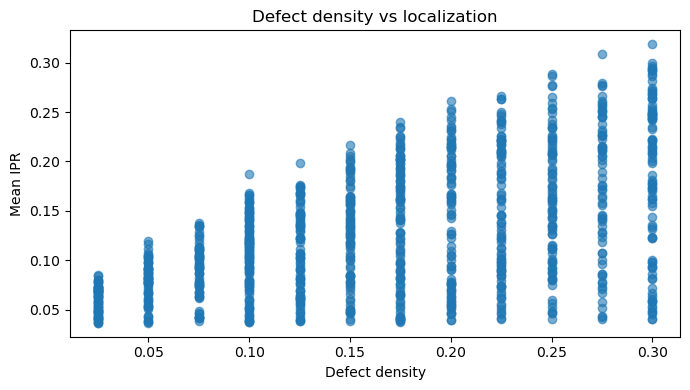

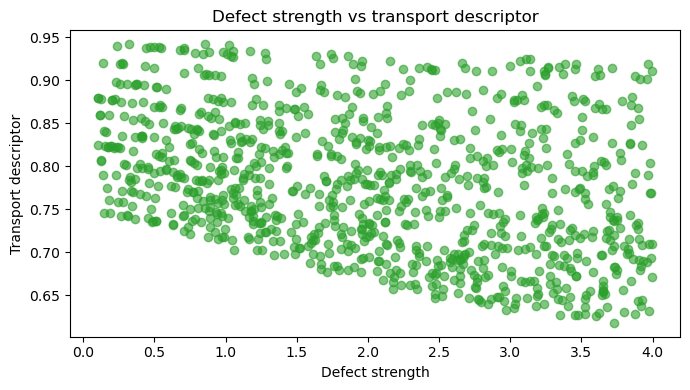

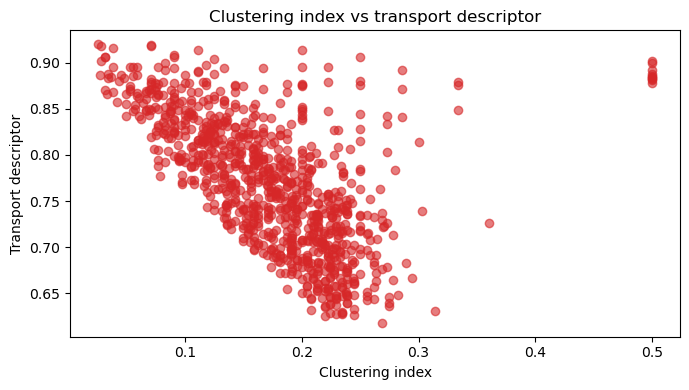

In [63]:
plt.figure(figsize=(7, 4))
plt.scatter(dataset['defect_density'], dataset['mean_ipr'], alpha=0.6)
plt.xlabel('Defect density')
plt.ylabel('Mean IPR')
plt.title('Defect density vs localization')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'defect_density_vs_mean_ipr_day3.png', dpi=200)
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(dataset['defect_strength'], dataset['transport_descriptor'], alpha=0.6, color='tab:green')
plt.xlabel('Defect strength')
plt.ylabel('Transport descriptor')
plt.title('Defect strength vs transport descriptor')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'defect_strength_vs_transport_day3.png', dpi=200)
plt.show()

plt.figure(figsize=(7, 4))
plt.scatter(dataset['clustering_index'], dataset['transport_descriptor'], alpha=0.6, color='tab:red')
plt.xlabel('Clustering index')
plt.ylabel('Transport descriptor')
plt.title('Clustering index vs transport descriptor')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'clustering_index_vs_transport_day3.png', dpi=200)
plt.show()

### Explanation of the code cell above

This cell creates exploratory scatter plots.

The plots examine relationships between:

- defect density and localization,
- defect strength and transport descriptor,
- clustering index and transport descriptor.

These figures help you visually inspect whether the synthetic dataset contains meaningful trends before training ML models.


## Feature and Target Columns for Notebook 4

In [64]:
feature_columns = [
    'n_defects',
    'defect_density',
    'defect_strength',
    'mean_defect_distance',
    'clustering_index',
    'energy_gap',
    'energy_bandwidth',
    'mean_ipr',
    'max_ipr',
]

target_column = 'transport_descriptor'

X = dataset[feature_columns]
y = dataset[target_column]

X.head(), y.head()

(   n_defects  defect_density  defect_strength  mean_defect_distance  \
 0          2           0.050         3.448532              4.000000   
 1          2           0.050         3.904927             19.000000   
 2          9           0.225         0.986231              4.125000   
 3          2           0.050         3.327762             14.000000   
 4          4           0.100         3.583172              7.666667   
 
    clustering_index  energy_gap  energy_bandwidth  mean_ipr   max_ipr  
 0          0.200000    0.128126          5.988623  0.091262  0.386841  
 1          0.050000    0.107560          6.361445  0.119007  0.722297  
 2          0.195122    0.194901          4.475552  0.096789  0.270611  
 3          0.066667    0.264142          5.862720  0.110990  0.743369  
 4          0.115385    0.126029          6.769371  0.161466  0.769479  ,
 0    0.876223
 1    0.855427
 2    0.756550
 3    0.861334
 4    0.792729
 Name: transport_descriptor, dtype: float64)

### Explanation of the code cell above

This cell separates the dataset into input features and target output.

`feature_columns` contains the variables that a machine-learning model will use as input.  
`target_column` is the quantity the model will try to predict: `transport_descriptor`.

`X` stores the input feature matrix, and `y` stores the target vector.

This is the standard structure used in scikit-learn workflows.


In [65]:
dataset[
    [
        "n_defects",
        "defect_density",
        "defect_strength",
        "mean_defect_distance",
        "clustering_index",
        "energy_gap",
        "energy_bandwidth",
        "mean_ipr",
        "max_ipr",
        "transport_descriptor",
    ]
].corr()

,n_defects,defect_density,defect_strength,mean_defect_distance,clustering_index,energy_gap,energy_bandwidth,mean_ipr,max_ipr,transport_descriptor
n_defects,1.000000,1.000000,-0.021781,-0.355624,0.564073,-0.128085,0.155894,0.539929,0.039694,-0.915467
defect_density,1.000000,1.000000,-0.021781,-0.355624,0.564073,-0.128085,0.155894,0.539929,0.039694,-0.915467
defect_strength,-0.021781,-0.021781,1.000000,-0.018955,0.056827,-0.033564,0.955276,0.736867,0.901022,-0.333387
mean_defect_distance,-0.355624,-0.355624,-0.018955,1.000000,-0.758774,0.086542,-0.104671,-0.172492,0.007541,0.298894
clustering_index,0.564073,0.564073,0.056827,-0.758774,1.000000,-0.128848,0.195741,0.261818,-0.025866,-0.487596
energy_gap,-0.128085,-0.128085,-0.033564,0.086542,-0.128848,1.000000,-0.066311,-0.120147,-0.039493,0.133277
energy_bandwidth,0.155894,0.155894,0.955276,-0.104671,0.195741,-0.066311,1.000000,0.811465,0.864682,-0.484146
mean_ipr,0.539929,0.539929,0.736867,-0.172492,0.261818,-0.120147,0.811465,1.000000,0.740754,-0.822099
max_ipr,0.039694,0.039694,0.901022,0.007541,-0.025866,-0.039493,0.864682,0.740754,1.000000,-0.377060
transport_descriptor,-0.915467,-0.915467,-0.333387,0.298894,-0.487596,0.133277,-0.484146,-0.822099,-0.377060,1.000000


### Explanation of the code cell above

This cell computes the correlation matrix between features and the transport descriptor.

Correlation values close to `+1` or `-1` indicate strong linear relationships. Values near `0` indicate weak linear relationships.

This is an exploratory tool. It does not capture all nonlinear effects, but it is useful for identifying which variables may be strongly connected to the target.


In [ ]:
plot_data = dataset.dropna(subset=["clustering_index", "transport_descriptor"])

plt.figure(figsize=(7, 5))

plt.scatter(
    plot_data["clustering_index"],
    plot_data["transport_descriptor"],
    alpha=0.7
)

plt.xlabel("Clustering index")
plt.ylabel("Transport descriptor")
plt.title("Clustering index vs transport descriptor")
plt.grid(True)
plt.tight_layout()
plt.show()

### Explanation of the code cell above

This cell focuses specifically on clustering index versus transport descriptor.

Rows with missing clustering values are removed using `dropna`, because clustering is not defined for single-defect cases.

The scatter plot helps answer whether closely grouped defects are associated with higher or lower transport behavior.


### Explanation of the placeholder cell above

This cell was empty in the original notebook. It can be used later for an additional plot, extra statistical check, or notes from your own interpretation.

For the current workflow, no code is necessary here.


## Day 3 Conclusion

Today, we generated a machine-learning-ready dataset from random hydrogen-defect configurations. Each row stores the defect configuration, spectral descriptors, localization descriptors, and a transport-related target value. This dataset will be used in Notebook 4 for classical machine learning prediction.

## Key learning takeaway

After running this notebook, focus on writing one or two sentences in your own words:

- What physical quantity was computed?
- Which feature or parameter changed?
- How did the result affect localization or transport?

This habit will help you turn code execution into scientific understanding.


## Final Formula Reminder

The core logic of this notebook can be summarized as

$$
\text{defect configuration} \rightarrow H \rightarrow \{E_n,\mathbf{c}^{(n)}\} \rightarrow \text{features} \rightarrow \text{prediction or optimization}.
$$

This is the main physics-informed workflow: we start from a material-inspired defect model, convert it into spectral and localization descriptors, and then use those descriptors for machine learning, interpretation, or optimization.
